# Tutorial 1
## Introduction to *scikit-learn*

This tutorial is based on https://github.com/ageron/handson-ml3/blob/main/01_the_machine_learning_landscape.ipynb


In [1]:
# Load python packages needed
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [7]:
file_url = 'https://raw.githubusercontent.com/mj-datalab/edu-repo/refs/heads/main/Python_ScikitLearn/lifesat.csv'
lifesat = pd.read_csv(file_url)
lifesat.head()


,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


Load provided dataset using Pandas. The dataset is a simple tabular dataset with two variables "GDP per capita (USD)" and "Life satisfaction". We choose "GDP per capita (USD)" as our only feature/predictor (X data) and "Life satisfaction" as our target variable (y data). X and y are our training data.

In [8]:
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

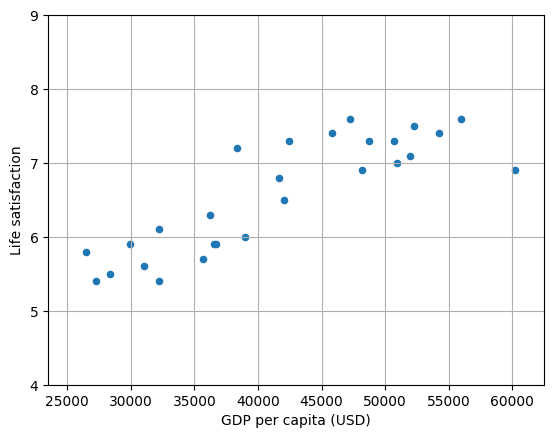

In [9]:
# Plot training data
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.show()

We are going to select a simple linear regression model, and train this model (estimate the model parameters using the training data).

In [10]:
# Select a linear model
model = LinearRegression()

# Train the model
model.fit(X, y)

LinearRegression()

We are now going to evaluate the model on a new data point (test data). We will use the GDP per capita (USD) for Cyprus (which was not in the training data) to make a new prediction of life satisfaction using the trained model.

In [11]:
# Make a prediction for Cyprus
X_new = [[37_655.2]]  # Cyprus' GDP per capita in 2020
y_pred = model.predict(X_new)
print(y_pred) # outputs [[6.30165767]]

[[6.30165767]]


Now let's plot everything together, the training data, the estimated (trained) linear model, and the prediction for the test data (Cyprus).

Text(29655.199999999997, 6.4, 'Cyprus: 6.3017')

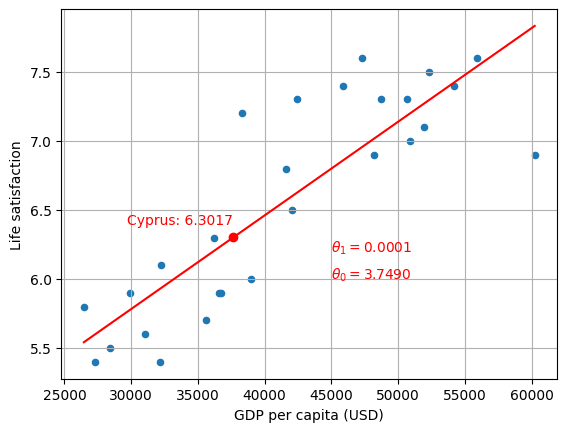

In [12]:
# Plot fitted model
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")

Xlin = np.linspace(X.min(), X.max(), 100)

w2 = model.coef_[0][0]
w1 = model.intercept_[0]
plt.plot(Xlin, w1 + w2 * Xlin, "r")
plt.text(45_000, 6, fr"$\theta_0 = {w1:.4f}$", color="r")
plt.text(45_000, 6.2, fr"$\theta_1 = {w2:.4f}$", color="r")

X_cyp = [37_655.2]

plt.plot(X_cyp, y_pred, "ro")

plt.text(X_cyp[0]-8000, 6.4, f"Cyprus: {y_pred[0][0]:.4f}", color="r")

It is very easy to select and train a different model. We need only to import the model, create a new model, in the below case we use K Nearest Neighbours, train and make a new prediction, as follows:

In [13]:
# Select a 3-Nearest Neighbors regression model
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)

# Train the model
model.fit(X, y)

# Make a prediction for Cyprus
print(model.predict(X_new)) # outputs [[6.33333333]]

[[6.33333333]]
